In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer
using GeometryBasics, StaticArrays

N_seg = 16       # number of wedges
R     = 1.0      # circle radius (m)
T_hot = 1000.0   # hot half-rim temperature (K)
kappa = 1.0      # absorption coefficient (m⁻¹)

# j runs one past N_seg at the last wedge; cos/sin wrap, closing the circle.
rim(j) = Point2(R * cos(2π * (j - 1) / N_seg), R * sin(2π * (j - 1) / N_seg))

faces     = PolyVolume2D{Float64}[]
divisions = Tuple{Int,Int}[]
for j in 1:N_seg
    verts = SVector(Point2(0.0, 0.0), rim(j), rim(j + 1))
    # Wall order follows vertex order: (spoke, rim, spoke).
    # Spokes are open — radiation passes freely between wedges —
    # so only the rim wall is a real surface.
    solidwalls = SVector(false, true, false)
    face = PolyVolume2D{Float64}(verts, solidwalls, 1, kappa, 0.0)
    face.T_in_w  = [0.0, j <= N_seg ÷ 2 ? T_hot : 0.0, 0.0]  # upper half hot
    face.epsilon = [1.0, 1.0, 1.0]
    face.T_in_g  = -1.0    # unknown (solve for this)
    face.q_in_g  = 0.0     # radiative equilibrium
    push!(faces, face)
    push!(divisions, (11, 11))
end

mesh = RayTracingDomain2D(faces, divisions; verbose = false);

In [3]:
mesh(10^7; method = :exchange, verbose = false)          # ray tracing
smooth!(mesh; verbose = false)                            # enforce energy conservation and reciprocity
solveEquilibrium!(mesh, mesh.F_smooth; verbose = false)   # solve the GERT system

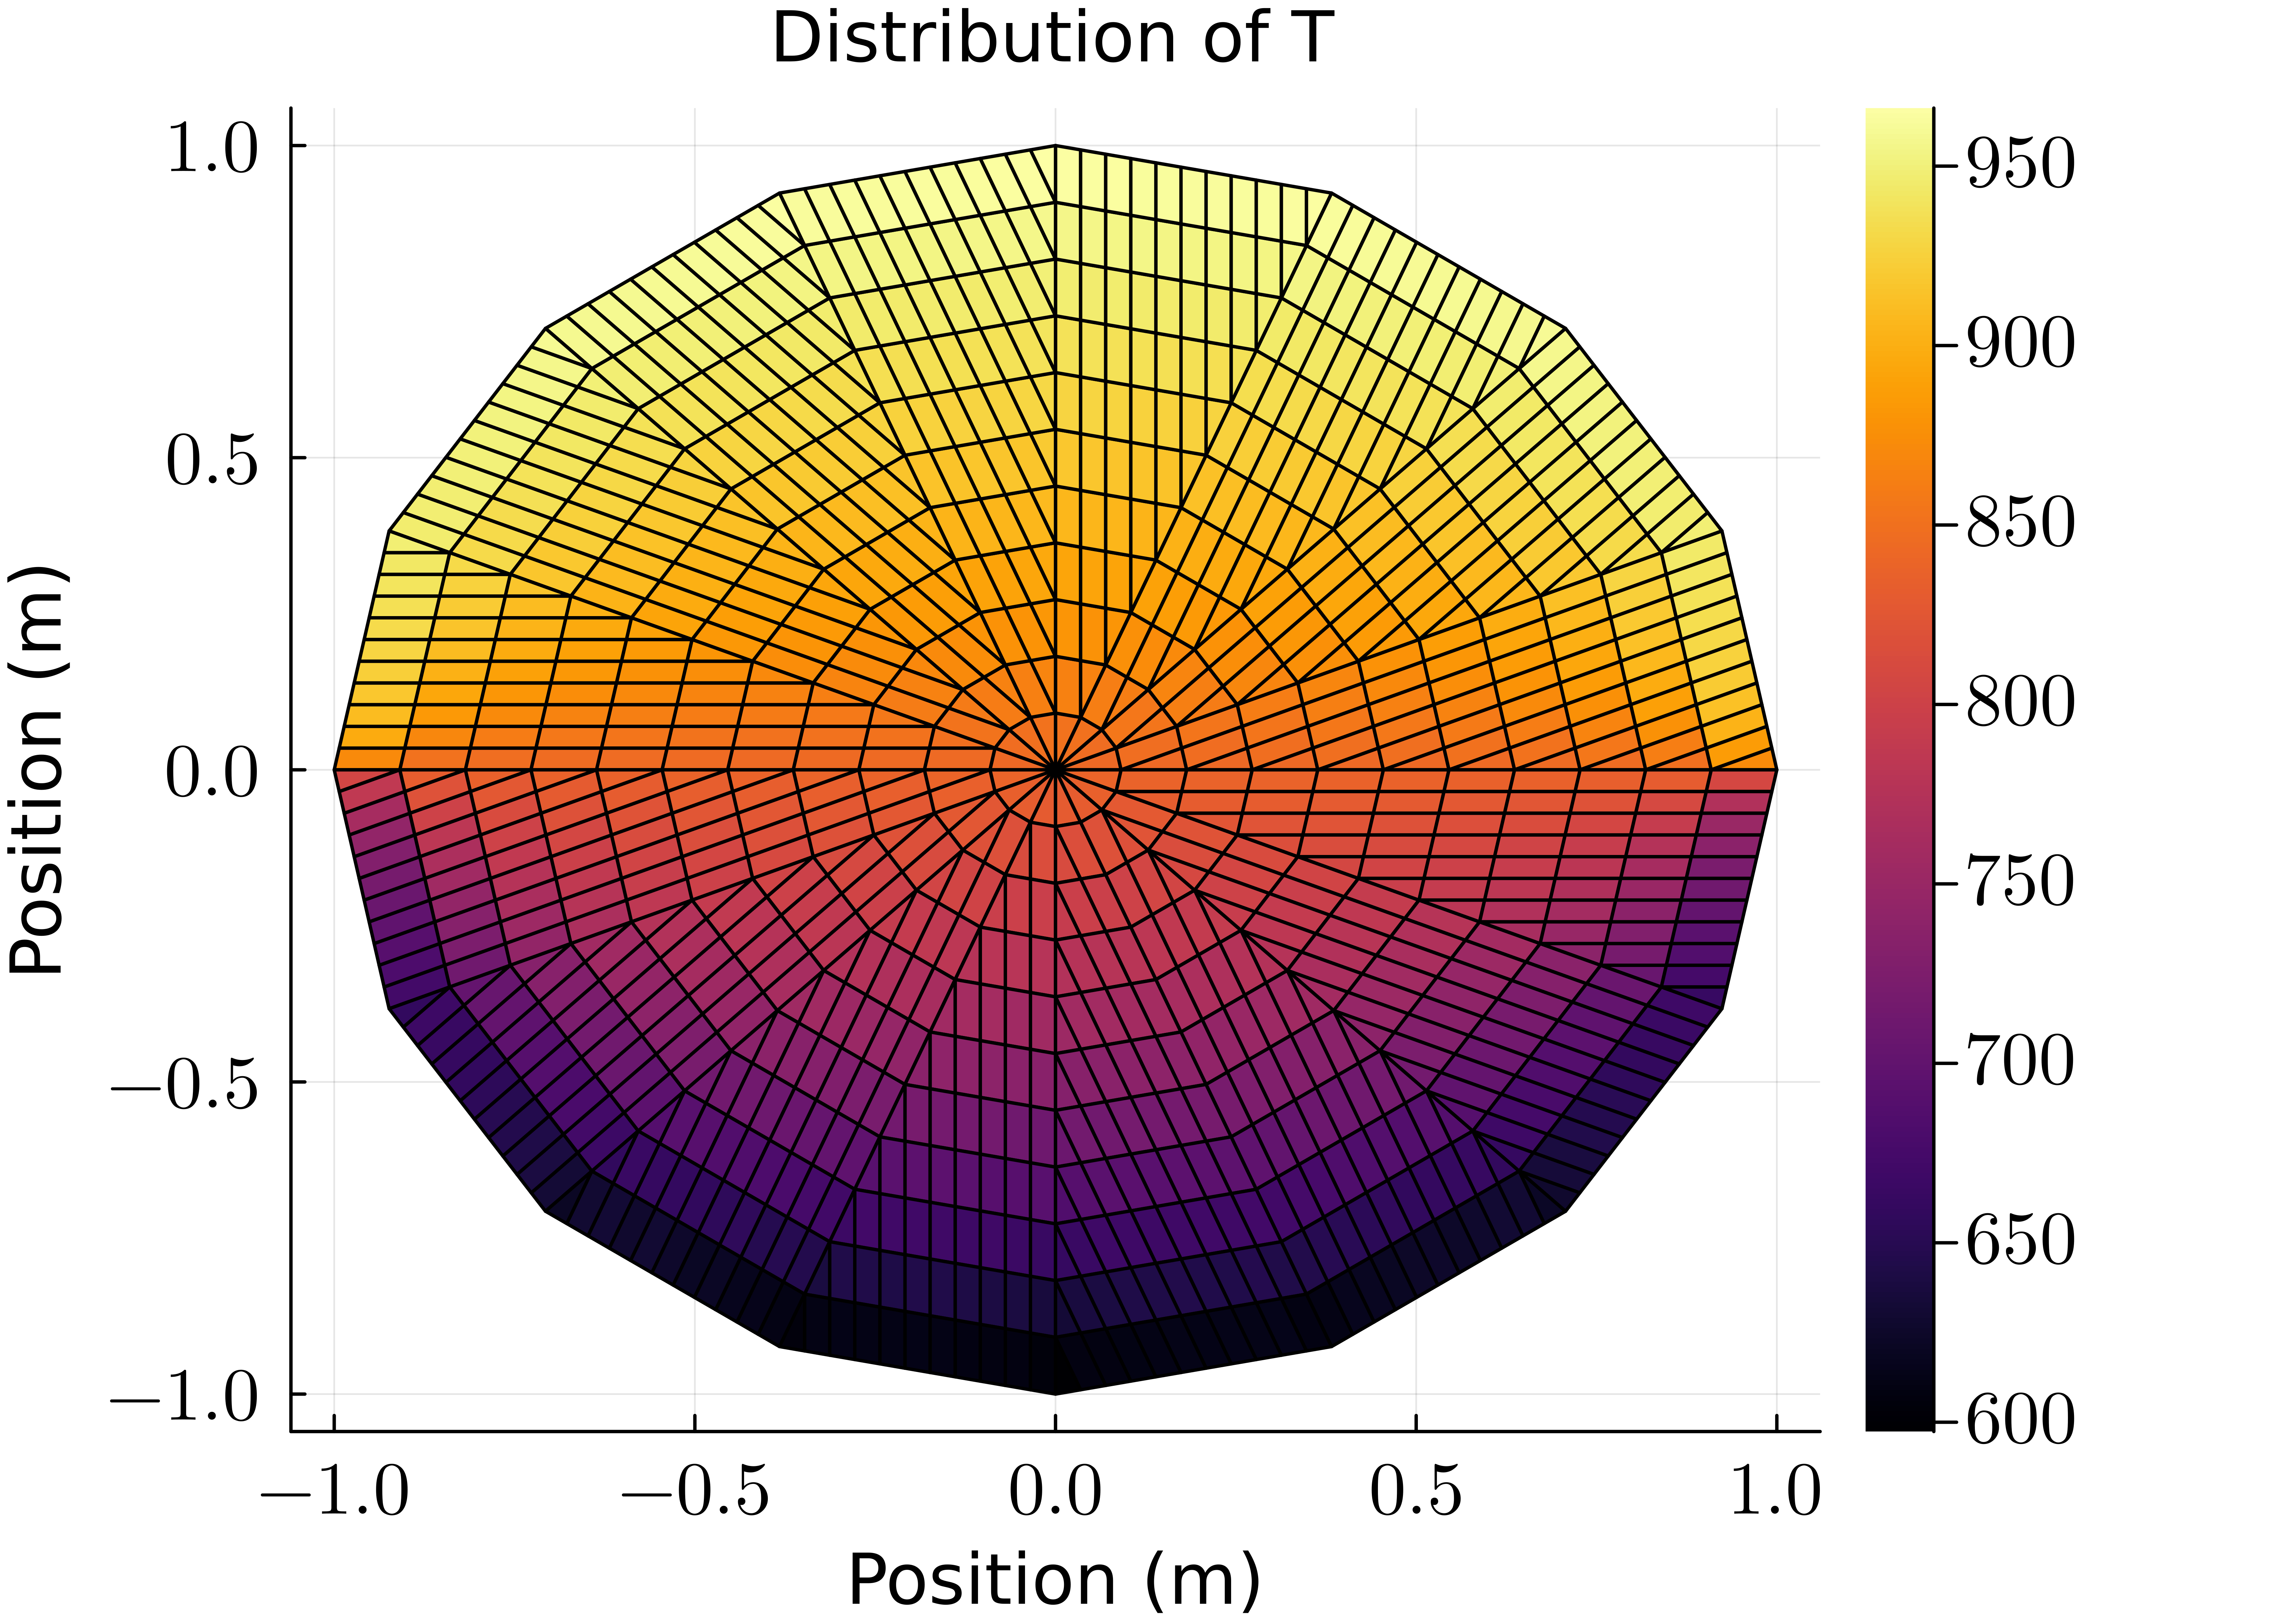

analytical centre limit : 840.8964 K
computed T⁴-mean        : 840.888 K
difference              : 0.0085 K


In [4]:
using Plots
using StatsBase

plotField(mesh; field = :T)

# Centre-limit validation: gas elements adjacent to the centre vertex.
# The GERT system is linear in emissive power, so swapping the hot and cold half-rims maps
# every centre cell onto its antipode with T⁴ + T⁴_antipode = T_hot⁴ + T_cold⁴ exactly, on any
# mesh. The symmetry therefore fixes the mean of T⁴ over the centre cells:
T_limit = ((T_hot^4 + 0.0^4) / 2)^(1/4)              # ≈ 840.896 K
T_g_mid = [fine[1].T_g for fine in mesh.fine_mesh]   # first fine element of each wedge
T_mean4 = (mean(T_g_mid .^ 4))^(1/4)                 # T⁴-mean of the centre cells
println("analytical centre limit : ", round(T_limit, digits = 4), " K")
println("computed T⁴-mean        : ", round(T_mean4, digits = 4), " K")
println("difference              : ", round(abs(T_limit - T_mean4), sigdigits = 2), " K")